In [6]:
import numpy as np
import random
import math
import matplotlib.pyplot as plt
from collections import defaultdict

# =========================================================
# 1. MAP
# =========================================================
# 0 = ô trống
# 1 = vật cản
#
# Bạn thay grid này bằng map của bạn.
# Ví dụ dưới đây chỉ là map mẫu 20x20.

grid20 = np.array([
    [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
    [0,0,1,1,1,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0],
    [0,0,1,0,1,0,0,1,1,1,0,0,0,0,0,0,1,1,1,0],
    [0,0,1,0,1,0,0,1,0,1,0,0,1,1,1,0,0,0,0,0],
    [0,0,1,0,0,0,0,1,0,1,0,0,0,0,1,0,0,1,0,0],
    [0,0,1,1,1,1,0,1,0,1,0,1,1,0,1,0,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0],
    [0,1,1,1,1,0,0,1,1,1,0,1,0,1,1,1,0,1,0,0],
    [0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,1,0,0],
    [0,1,1,0,1,0,1,1,0,1,0,1,1,1,0,1,0,1,0,0],
    [0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0],
    [0,1,1,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,0,0],
    [0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0],
    [0,1,1,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,0],
    [0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0],
    [0,1,1,1,0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,0],
    [0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0],
    [0,1,0,1,1,1,0,1,1,1,0,1,1,1,1,1,0,1,0,0],
    [0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
    [0,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,0,0,0,0],
], dtype=int)

grid30 = np.array([
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,1,1,1,1,1,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,1,0,0,1,1,1,0,0,0,0],
 [0,0,1,1,1,1,0,0,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,0,0,0,0],
 [1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1],
 [1,1,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,1,1,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,0,1,0,0,0,0,0,0],
 [0,0,0,0,0,1,1,1,0,0,1,1,1,0,0,0,0,0,1,1,1,1,0,0,0,0,1,0,1,0],
 [0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,1,1,1,0,0,0,1,0,0,1,1,1,1,1,0,0,1,0,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0],
 [0,0,0,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0],
 [1,0,0,0,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1],
 [0,0,1,0,0,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0],
 [0,0,0,0,0,0,0,1,1,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0],
 [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1],
 [0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,1,1,1,1],
 [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,1,0,0,0,0,0,0,0],
], dtype=np.int8)

Training xong.
Số bước: 44
Đã đi đủ goal chưa: True
Độ dài đường đi: 48.971


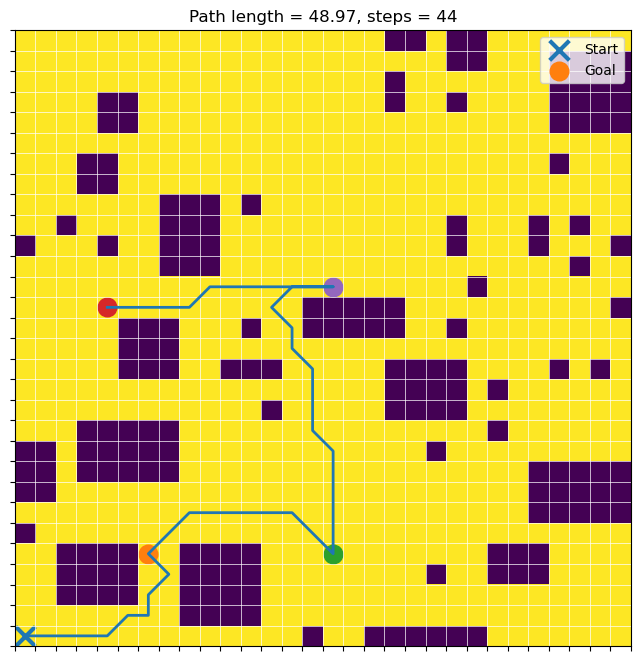

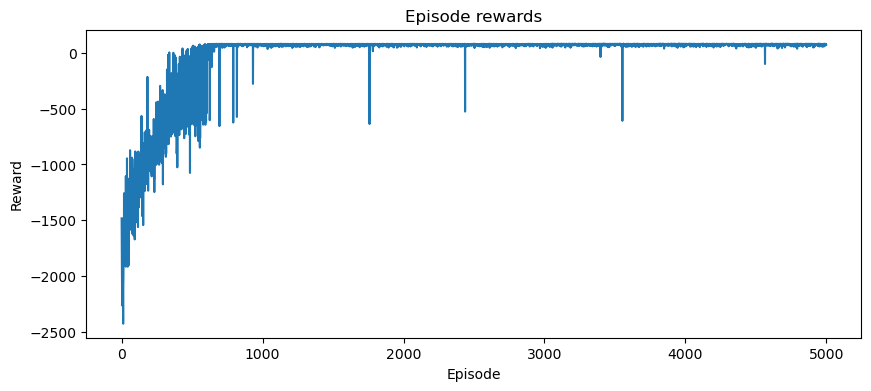

[(4, 6), (4, 15), (16, 4), (17, 15)]

In [7]:
grid = grid30  # chọn grid nào để chạy
ROWS, COLS = grid.shape

start = (0, 0)
#goals = [(4, 5), (4, 15), (16, 4), (16, 15)]  # thay bằng goal của bạn
goals = [(4, 6), (4, 15), (16, 4), (17, 15)]
# =========================================================
# 2. ACTION SPACE: 8 hướng
# =========================================================
# 0: lên, 1: xuống, 2: trái, 3: phải
# 4: chéo lên trái, 5: chéo lên phải, 6: chéo xuống trái, 7: chéo xuống phải
ACTIONS = [
    (-1,  0),  # up
    ( 1,  0),  # down
    ( 0, -1),  # left
    ( 0,  1),  # right
    (-1, -1),  # up-left
    (-1,  1),  # up-right
    ( 1, -1),  # down-left
    ( 1,  1),  # down-right
]

# cost cho từng action: thẳng = 1, chéo = sqrt(2)
ACTION_COST = [1.0, 1.0, 1.0, 1.0, math.sqrt(2), math.sqrt(2), math.sqrt(2), math.sqrt(2)]

# =========================================================
# 3. HÀM HỖ TRỢ
# =========================================================
def in_bounds(r, c):
    return 0 <= r < ROWS and 0 <= c < COLS

def is_free(r, c):
    return in_bounds(r, c) and grid[r, c] == 0

def goal_to_bit(goal_idx):
    return 1 << goal_idx

def all_goals_mask():
    return (1 << len(goals)) - 1

def update_visited_mask(pos, visited_mask):
    """Nếu pos trùng 1 goal chưa thăm thì bật bit goal đó."""
    for i, g in enumerate(goals):
        if pos == g:
            visited_mask |= goal_to_bit(i)
    return visited_mask

def get_valid_next_position(r, c, action_idx):
    """
    Chặn:
    - đi ra ngoài map
    - đi vào obstacle
    - diagonal corner cutting:
      nếu đi chéo thì 2 ô cạnh cũng phải trống
    """
    dr, dc = ACTIONS[action_idx]
    nr, nc = r + dr, c + dc

    if not is_free(nr, nc):
        return None

    # Nếu đi chéo, không cho cắt góc obstacle
    if dr != 0 and dc != 0:
        if not is_free(r + dr, c) or not is_free(r, c + dc):
            return None

    return (nr, nc)

def state_key(pos, visited_mask):
    return (pos[0], pos[1], visited_mask)

# =========================================================
# 4. REWARD DESIGN
# =========================================================
def compute_reward(prev_pos, next_pos, visited_before, visited_after, action_idx):
    """
    Ý tưởng giống paper:
    - mỗi bước bị phạt
    - đến goal được thưởng
    - đụng vật cản sẽ bị phạt lớn (xử lý ở ngoài)
    """
    reward = -ACTION_COST[action_idx]  # bước đi càng dài, phạt càng nhiều

    # thưởng nếu vừa chạm goal mới
    if visited_after != visited_before:
        reward += 20.0

    return reward

# =========================================================
# 5. Q-LEARNING
# =========================================================
# Q[state][action]
Q = defaultdict(lambda: np.zeros(len(ACTIONS), dtype=float))

alpha = 0.1
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.995

episodes = 5000
max_steps_per_episode = 500

episode_rewards = []

for ep in range(episodes):
    pos = start
    visited_mask = update_visited_mask(pos, 0)

    total_reward = 0.0

    for step in range(max_steps_per_episode):
        s = state_key(pos, visited_mask)

        # epsilon-greedy
        if random.random() < epsilon:
            action = random.randint(0, len(ACTIONS) - 1)
        else:
            action = int(np.argmax(Q[s]))

        next_pos = get_valid_next_position(pos[0], pos[1], action)

        # va obstacle / action không hợp lệ
        if next_pos is None:
            reward = -10.0
            s_next = s
            Q[s][action] += alpha * (
                reward + gamma * np.max(Q[s_next]) - Q[s][action]
            )
            total_reward += reward
            continue

        visited_after = update_visited_mask(next_pos, visited_mask)
        reward = compute_reward(pos, next_pos, visited_mask, visited_after, action)

        s_next = state_key(next_pos, visited_after)

        # update Q
        Q[s][action] += alpha * (
            reward + gamma * np.max(Q[s_next]) - Q[s][action]
        )

        pos = next_pos
        visited_mask = visited_after
        total_reward += reward

        # done nếu đi qua hết goal
        if visited_mask == all_goals_mask():
            total_reward += 50.0
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    episode_rewards.append(total_reward)

print("Training xong.")

# =========================================================
# 6. SUY LUẬN PATH SAU KHI HỌC
# =========================================================
def extract_path(Q, start, goals, max_steps=500):
    pos = start
    visited_mask = update_visited_mask(pos, 0)
    path = [pos]

    for _ in range(max_steps):
        s = state_key(pos, visited_mask)
        action = int(np.argmax(Q[s]))
        next_pos = get_valid_next_position(pos[0], pos[1], action)

        # nếu action tốt nhất bị invalid thì thử action tốt tiếp theo
        if next_pos is None:
            sorted_actions = np.argsort(Q[s])[::-1]
            found = False
            for a in sorted_actions:
                cand = get_valid_next_position(pos[0], pos[1], int(a))
                if cand is not None:
                    action = int(a)
                    next_pos = cand
                    found = True
                    break
            if not found:
                break

        pos = next_pos
        visited_mask = update_visited_mask(pos, visited_mask)
        path.append(pos)

        if visited_mask == all_goals_mask():
            break

    return path, visited_mask

path, final_mask = extract_path(Q, start, goals)
print("Số bước:", len(path) - 1)
print("Đã đi đủ goal chưa:", final_mask == all_goals_mask())

# =========================================================
# 7. TÍNH ĐỘ DÀI ĐƯỜNG ĐI
# =========================================================
def path_length(path):
    total = 0.0
    for i in range(1, len(path)):
        r1, c1 = path[i - 1]
        r2, c2 = path[i]
        dr = abs(r2 - r1)
        dc = abs(c2 - c1)
        if dr == 1 and dc == 1:
            total += math.sqrt(2)
        else:
            total += 1.0
    return total

print("Độ dài đường đi:", round(path_length(path), 3))

# =========================================================
# 8. VẼ KẾT QUẢ
# =========================================================
def plot_result(grid, start, goals, path):
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap="viridis_r")

    # grid line
    rows, cols = grid.shape
    plt.xticks(np.arange(-0.5, cols, 1), [])
    plt.yticks(np.arange(-0.5, rows, 1), [])
    plt.grid(color="white", linewidth=0.5)

    # start
    plt.scatter(start[1], start[0], marker='x', s=200, linewidths=3, label='Start')

    # goals
    for i, (r, c) in enumerate(goals):
        plt.scatter(c, r, s=180, marker='o', label='Goal' if i == 0 else None)

    # path
    if len(path) > 1:
        xs = [p[1] for p in path]
        ys = [p[0] for p in path]
        plt.plot(xs, ys, linewidth=2)

    plt.title(f"Path length = {path_length(path):.2f}, steps = {len(path)-1}")
    plt.legend()
    plt.gca().invert_yaxis()
    plt.show()

plot_result(grid, start, goals, path)

# =========================================================
# 9. VẼ REWARD THEO EPISODE
# =========================================================
plt.figure(figsize=(10, 4))
plt.plot(episode_rewards)
plt.title("Episode rewards")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.show()
[(4, 6), (4, 15), (16, 4), (17, 15)]